# 02 — XGBoost (Gradient Boosting)

**Was dieses Notebook tut:** Es trainiert das erste *nichtlineare* Modell für die Frage
*"Wird diese Buchung storniert?"* — den ersten ernsthaften Herausforderer der
LogReg-Baseline aus 01. XGBoost baut viele kleine Entscheidungsbäume nacheinander, wobei
jeder Baum die Fehler seiner Vorgänger korrigiert (Boosting). Es erfasst Interaktionen
und Nichtlinearitäten, die die LogReg per Konstruktion nicht sehen kann.

**Bewusst gleiche Struktur wie 01** — nur fünf Stellen unterscheiden sich, und genau die
sind hier inhaltlich interessant:

| § | gleich wie 01? | Unterschied |
|---|---|---|
| §4 Preprocessing | **nein** | Kein Scaling (Bäume sind skaleninvariant); One-Hot bleibt, aber `company_prior_cancel_rate` behält **NaN** → XGBoost lernt die Default-Richtung selbst (statt 01s erzwungenem 0-Fill) |
| §5 Modell | **nein** | XGBoost statt LogReg |
| §6b Encoding-Benchmark | **neu** | *probieren & das Beste nehmen*: One-Hot vs. native Kategorien vs. ordinal, empirisch auf Zeit-CV |
| §6c Hyperparameter-Suche | **neu** | Early Stopping + RandomizedSearch auf Train (Test/Val bleiben unberührt) |
| §11 XAI | **nein** | Gain-Importances + exaktes TreeSHAP statt Koeffizienten |

**Workflow** (so arbeitet ein ML Engineer):

1. Daten laden (sauberes Parquet aus 00 — eine Quelle der Wahrheit)
2. Features auswählen (identische Liste wie 01 → fairer Vergleich in 05)
3. Zeitlicher Split train/val/test (fertig aus 00)
4. Preprocessing-Pipeline (baum-gerecht)
5. Modell definieren (XGBoost + Kalibrierung)
6. CV-Stabilität → Encoding-Benchmark → Hyperparameter-Suche (*das Beste nehmen*)
7. Fit auf Train → Metriken auf **Val**
8. Threshold-Tuning auf **Val**
9. Finaler Lauf auf **Test** — genau EINMAL
10. Slice-Analyse (pro Hotel/Kanal/Lead-Time)
11. XAI: Gain, Permutation, PDP/ICE, SHAP
12. Alles speichern (Modell, Predictions, Model Card)

> **Die eiserne Regel:** Das Test-Set wird für KEINE Entscheidung benutzt.
> Tuning & Modellwahl passieren auf Train/Val. Test liefert nur am Ende die ehrliche Zahl.


In [ ]:
# =============================================================================
# §0 SETUP — Imports, Projekt-Pfade, Plot-Stil
# =============================================================================
from __future__ import annotations

import sys, json, warnings
from pathlib import Path

# Projekt-Root finden (Ordner mit pyproject.toml), damit "from src import ..." klappt.
_here = Path.cwd().resolve()
while not (_here / "pyproject.toml").exists():
    _here = _here.parent
if str(_here) not in sys.path:
    sys.path.insert(0, str(_here))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Projekt-Helfer (siehe 01) — identische Quelle der Wahrheit fuer Laden + Branding.
from src import (apply_stayery_style, color, load_clean_reservations,
                 figures_dir, tables_dir)

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
apply_stayery_style()
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 200)

# Output-Ordner fuer DIESES Notebook (parallel zu 01_logreg).
FIG = figures_dir() / "02_xgboost";  FIG.mkdir(parents=True, exist_ok=True)
TAB = tables_dir()  / "02_xgboost";  TAB.mkdir(parents=True, exist_ok=True)

# -----------------------------------------------------------------------------
# SCHALTER: FAST_DEV = True  -> kleiner Datenausschnitt, weniger CV-Folds und
# kleinere Hyperparameter-Suche. Zum schnellen Ausprobieren. Echte Ergebnisse: False.
# -----------------------------------------------------------------------------
FAST_DEV = False
SEED = 42

print(f"Setup ok. Projekt: {_here.name} | FAST_DEV={FAST_DEV}")


Setup ok. Projekt: OverbookingAnalyse | FAST_DEV=False


## §1 — Daten laden

Wir laden **nur** das fertige, saubere Parquet aus Notebook 00 — exakt wie 01. Alles
Cleaning (Duplikate, Ausreißer, COVID-Floor 2022-08, Leakage-Spalten raus) ist dort
passiert und dokumentiert. Eine Quelle der Wahrheit, identische Datenbasis wie die
Baseline → der Vergleich in 05 ist fair.

Zielfeld `status`: **1 = storniert, 0 = angereist** (NoShows in 00 ausgeschlossen).

In [ ]:
# =============================================================================
# §1 DATEN LADEN  (identisch zu 01 — gleiche Datenbasis = fairer Vergleich)
# =============================================================================
df = load_clean_reservations()
df = df.rename(columns={"status": "is_cancelled"})

if FAST_DEV:
    df = df.iloc[::5].copy()   # jede 5. Zeile, zeitlich gleichmaessig

print(f"{len(df):,} Buchungen | Anreisen {df['arrival'].min().date()} .. {df['arrival'].max().date()}")
print(f"Storno-Quote gesamt: {df['is_cancelled'].mean():.1%}")
df.head(3)


169,617 Buchungen | Anreisen 2022-08-01 .. 2026-06-07
Storno-Quote gesamt: 20.7%


,is_cancelled,travelPurpose,property_name,unitGroup_name,channelCode,primaryGuest_preferredLanguage,primaryGuest_address_countryCode,guaranteeType,cancellationFee_name,arrival,departure,created,lead_time_days,los_nights,gross_amount,gross_per_night,company_name_clean,ratePlan_type,ratePlan_category,has_group,diff_gross_cancellation_fee,adults_n,has_promo,has_corporate_code,has_children,guest_country_region,arrival_dow,arrival_month,is_weekend_arrival,stay_bucket,log_gross_amount,has_company,company_prior_bookings,company_prior_cancel_rate,is_repeat_company,temporal_split,is_temporal_test,is_temporal_val
0,1,Leisure,Bochum Ehrenfeld,BIG,Airbnb,NaN,NaN,CreditCard,Airbnb,2026-06-07 13:00:00+00:00,2026-06-08 09:00:00+00:00,2026-06-07 11:44:42+00:00,0.052292,1,68.99,68.99,NaN,flexible,airbnb shortstay,0,0.0,1,0,0,0,Unknown,6,6,1,short,4.248352,0,0,<NA>,0,test,1,0
1,1,Leisure,Bochum Ehrenfeld,BIGGER,Airbnb,NaN,NaN,CreditCard,Airbnb,2026-05-09 13:00:00+00:00,2026-05-10 09:00:00+00:00,2026-05-07 21:08:58+00:00,1.660440,1,130.99,130.99,NaN,flexible,airbnb shortstay,0,0.0,2,0,0,0,Unknown,5,5,1,short,4.882726,0,0,<NA>,0,test,1,0
2,1,NaN,Bochum Ehrenfeld,BIG,Direct,NaN,NaN,CreditCard,Flexible,2025-09-24 13:00:00+00:00,2025-09-25 09:00:00+00:00,2025-09-24 06:00:25+00:00,0.291377,1,12.00,12.0,BD Apartment GmbH,comp,comp,0,12.0,1,1,0,0,Unknown,2,9,0,short,2.564949,1,29,0.551724,1,val,0,1


## §2 — Feature-Auswahl (was darf das Modell sehen?)

**Identische Feature-Liste wie 01** — das ist die Voraussetzung für einen fairen
Modellvergleich in 05 (gleiche Features, gleiche Splits, nur das Modell ändert sich).
Was sich ändert, ist die *Behandlung* der Features (§4), nicht ihre Auswahl.

| Gruppe | Behandlung bei Bäumen | Warum anders als 01 |
|---|---|---|
| **Numerisch** | unverändert durchreichen (kein Scaling) | Bäume splitten an Schwellen — Skala egal |
| **Numerisch (History)** | **NaN bleibt NaN** → XGBoost lernt die Default-Richtung | 01 musste 0-füllen (LogReg verträgt kein NaN). Bei Bäumen ist das ein echter Nachteil: 0-Füllen verwechselt *"keine Historie"* mit *"0 % Stornoquote"*. Native NaN-Behandlung trennt beides sauber. |
| **Kategorisch** | One-Hot (0/1-Spalten), `handle_unknown="ignore"` | siehe Encoding-Benchmark §6b — bei dieser niedrigen Kardinalität die robusteste Wahl |

**Bewusst ausgeschlossen** (identisch zu 01, zentral via `src/features.py NON_FEATURE_COLS`):
`arrival/departure/created` (Zeitanker), die drei Check-in-Leakage-Profilfelder
(`guest_country_region`, `preferredLanguage`, `travelPurpose`, entfernt 2026-06-12),
`company_name_clean` (ersetzt durch History-Bundle), `ratePlan_type` (redundant zu
`ratePlan_category`, offene Entscheidung #1), `gross_amount` (wir nutzen den Log),
sowie die Split-Spalten.

In [ ]:
# =============================================================================
# §2 FEATURE-LISTEN - aus dem ROSTER (Data/feature_roster.json, 00 §11)
# =============================================================================
# IDENTISCH zu 01: beide laden denselben Roster -> fairer Vergleich in 05.
from src import roster_features

NUM_FEATURES, CAT_FEATURES = roster_features()
NUM_HISTORY: list[str] = []          # company history excluded by roster (leakage)
TARGET = "is_cancelled"

_missing = [c for c in NUM_FEATURES + NUM_HISTORY + CAT_FEATURES + [TARGET] if c not in df.columns]
assert not _missing, f"Fehlende Spalten (00 neu laufen lassen?): {_missing}"

# Dtype-Hygiene: to_numeric(...).astype(float64) ERHAELT NaN (XGBoost-natives NaN).
for c in NUM_FEATURES + NUM_HISTORY:
    df[c] = pd.to_numeric(df[c], errors="coerce").astype("float64")
for c in CAT_FEATURES:
    df[c] = df[c].astype("object")
df[TARGET] = df[TARGET].astype("int64")

print(f"{len(NUM_FEATURES) + len(NUM_HISTORY)} numerische + {len(CAT_FEATURES)} kategorische Features (Roster).")

17 numerische + 7 kategorische Features.
NaN-Anteil company_prior_cancel_rate (bleibt bewusst NaN): 75.2%


## §3 — Zeitlicher Split: train / val / test

Identisch zu 01: der Split kommt **fertig aus Notebook 00** (Spalte `temporal_split`,
60 % / 15 % / 25 % nach Anreise). train = lernen · val = Tuning & Threshold · test =
einmalige Endabnahme. Zeitlich statt zufällig, damit kein Zukunftswissen ins Training
sickert (das wäre Leakage und würde die Testzahl schönen).

In [ ]:
# =============================================================================
# §3 SPLIT ANWENDEN  (identisch zu 01)
# =============================================================================
m_train = df["temporal_split"] == "train"
m_val   = df["temporal_split"] == "val"
m_test  = df["temporal_split"] == "test"

FEATURES = NUM_FEATURES + NUM_HISTORY + CAT_FEATURES
X_train, y_train = df.loc[m_train, FEATURES], df.loc[m_train, TARGET]
X_val,   y_val   = df.loc[m_val,   FEATURES], df.loc[m_val,   TARGET]
X_test,  y_test  = df.loc[m_test,  FEATURES], df.loc[m_test,  TARGET]

# Train chronologisch sortieren (Pflicht fuer TimeSeriesSplit in §6).
_order  = df.loc[m_train, "arrival"].sort_values(kind="mergesort").index
X_train = X_train.loc[_order]
y_train = y_train.loc[_order]

for name, m in [("train", m_train), ("val", m_val), ("test", m_test)]:
    sub = df.loc[m]
    print(f"{name:5s}: {m.sum():>7,} Zeilen | Anreisen {sub['arrival'].min().date()} .. "
          f"{sub['arrival'].max().date()} | Storno {sub[TARGET].mean():.1%}")


train: 101,649 Zeilen | Anreisen 2022-08-01 .. 2025-05-24 | Storno 21.3%
val  :  25,563 Zeilen | Anreisen 2025-05-24 .. 2025-11-07 | Storno 19.9%
test :  42,405 Zeilen | Anreisen 2025-11-07 .. 2026-06-07 | Storno 19.8%


## §4 — Preprocessing-Pipeline (baum-gerecht)

Drei bewusste Unterschiede zu 01s Pipeline:

1. **Kein StandardScaler.** Entscheidungsbäume splitten an Schwellenwerten
   (`lead_time > 30?`) — die Skala eines Features ist völlig egal. Scaling wäre
   verschwendete Rechenzeit und würde die Importances unnötig verzerren.
2. **Kein Imputer für die Numerik.** Die 16 Standard-Numerics haben in 00 bereits
   0 % fehlende Werte. Und `company_prior_cancel_rate` reichen wir **mit NaN** durch:
   XGBoost lernt pro Split die optimale Richtung für fehlende Werte selbst. So bleibt
   *"keine Firmenhistorie"* ein eigener Zustand und wird nicht mit *"0 % Stornoquote"*
   verwechselt — ein echter methodischer Gewinn gegenüber 01.
3. **One-Hot wie in 01**, mit `handle_unknown="ignore"`: taucht später ein neuer
   Kanal/Tarif auf (neue Hotels!), gibt es überall 0 statt eines Absturzes.

Die Begründung *warum One-Hot und nicht native Kategorien* liefert §6b empirisch.

In [ ]:
# =============================================================================
# §4 PREPROCESSOR — One-Hot fuer Kategorien, Numerik unveraendert durchreichen
# =============================================================================
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

NUM_ALL = NUM_FEATURES + NUM_HISTORY   # alle Numerik-Spalten zusammen

preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), CAT_FEATURES),  # Text -> 0/1-Spalten
    ("num", "passthrough", NUM_ALL),                                # Zahlen 1:1 (NaN bleibt!)
])

# Dimensions-Check + Beweis, dass NaN die Pipeline ueberlebt (native Behandlung).
_demo = preprocessor.fit_transform(X_train)
_arr  = _demo.toarray() if hasattr(_demo, "toarray") else np.asarray(_demo)
print(f"Aus {len(FEATURES)} Roh-Features werden {_arr.shape[1]} Modell-Spalten (nach One-Hot).")
print(f"NaN in der Modell-Matrix vorhanden (history -> XGBoost-nativ): {np.isnan(_arr).any()}")


Aus 24 Roh-Features werden 112 Modell-Spalten (nach One-Hot).
NaN in der Modell-Matrix vorhanden (history -> XGBoost-nativ): True


## §5 — Modell: XGBoost + Kalibrierung

**XGBoost** (Extreme Gradient Boosting) baut Bäume sequentiell: Baum *t+1* lernt auf den
Residuen der ersten *t* Bäume. Stärken hier: erfasst Feature-Interaktionen automatisch
(z. B. "OTA-Kanal **und** kurze Lead-Time"), behandelt NaN nativ, ist robust gegen
Ausreißer und braucht kein Scaling.

**Baseline-Hyperparameter** (offene Entscheidung #6): `n_estimators=600, max_depth=6,
learning_rate=0.05`, `tree_method="hist"` (schnell), `importance_type="gain"` (für §11a).
Diese Werte sind ein vernünftiger Startpunkt — die *getunten* Werte findet §6c.

**Kalibrierung (isotonic, cv=5):** Wie in 01. Baum-Wahrscheinlichkeiten sind oft leicht
verzerrt; fürs Overbooking rechnen wir mit *erwarteten Stornos*, brauchen also ehrliche
Wahrscheinlichkeiten. `CalibratedClassifierCV` lernt die Korrektur auf 5 internen Falten.

**Bewusst KEIN `scale_pos_weight`** (das XGB-Pendant zu `class_weight="balanced"`): Das
würde die Wahrscheinlichkeiten verzerren — genau wie bei 01 behandeln wir die Klassen-
Schieflage (21 / 79) über den **Threshold** in §8, nicht über das Modell.

In [ ]:
# =============================================================================
# §5 MODELL DEFINIEREN  (Baseline; getunt wird in §6c)
# =============================================================================
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.calibration import CalibratedClassifierCV

# Gemeinsame Grund-Einstellungen (an EINER Stelle, damit alle Folgezellen sie teilen).
XGB_FIXED = dict(
    tree_method="hist",        # schneller Histogramm-Algorithmus
    eval_metric="logloss",     # interne Trainingsmetrik
    importance_type="gain",    # feature_importances_ = mittlerer Gain (fuer §11a)
    random_state=SEED,
    n_jobs=-1,
    # missing=np.nan ist Default -> NaN wird nativ behandelt.
)
# Baseline-Hyperparameter (offene Entscheidung #6).
BASE_PARAMS = dict(n_estimators=600, max_depth=6, learning_rate=0.05, subsample=1.0,
                   colsample_bytree=1.0, min_child_weight=1, reg_lambda=1.0)

base_xgb = XGBClassifier(**XGB_FIXED, **BASE_PARAMS)

# Kalibrier-Huelle (wie 01): 5 interne Falten lernen die Wahrscheinlichkeits-Korrektur.
calibrated = CalibratedClassifierCV(estimator=base_xgb, method="isotonic", cv=5)

# Komplett-Pipeline: Preprocessing + kalibriertes Modell in EINEM Objekt.
model = Pipeline([("prep", preprocessor), ("clf", calibrated)])
model


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains spa

## §6 — Cross-Validation auf Train (Stabilitäts-Check)

Wie 01: bevor wir einem Fit vertrauen, prüfen wir, wie stark die Qualität über
Zeitabschnitte schwankt.

- **TimeSeriesSplit (primär):** trainiert auf Vergangenheit, prüft auf der folgenden
  Periode — simuliert den Produktionsfall.
- **StratifiedKFold (Diagnose):** zufällige Falten. Ist Zufalls-CV deutlich besser als
  Zeit-CV → das Modell lebt von Drift/Zukunftswissen (Warnsignal). Sind beide ähnlich →
  Muster sind zeitstabil. ✓

Hier läuft das **unkalibrierte** Baseline-Modell (Kalibrierung ändert die Rangfolge der
Scores nicht, also auch nicht die AUC — spart 5× Rechenzeit).

In [ ]:
# =============================================================================
# §6 DUAL-CV: ZEITLICH (primaer) vs ZUFAELLIG (Diagnose) — auf Baseline
# =============================================================================
from sklearn.model_selection import TimeSeriesSplit, StratifiedKFold, cross_validate

cv_pipeline = Pipeline([("prep", preprocessor), ("clf", XGBClassifier(**XGB_FIXED, **BASE_PARAMS))])
n_folds = 3 if FAST_DEV else 5

tss = TimeSeriesSplit(n_splits=n_folds)
res_time = cross_validate(cv_pipeline, X_train, y_train, cv=tss,
                          scoring=["roc_auc", "average_precision"], n_jobs=1)

skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=SEED)
res_rand = cross_validate(cv_pipeline, X_train, y_train, cv=skf,
                          scoring=["roc_auc", "average_precision"], n_jobs=1)

cv_table = pd.DataFrame({
    "cv":  ["TimeSeriesSplit (primaer)", "StratifiedKFold (Diagnose)"],
    "auc_mean": [res_time["test_roc_auc"].mean(),  res_rand["test_roc_auc"].mean()],
    "auc_std":  [res_time["test_roc_auc"].std(),   res_rand["test_roc_auc"].std()],
    "ap_mean":  [res_time["test_average_precision"].mean(), res_rand["test_average_precision"].mean()],
}).round(4)
cv_table.to_csv(TAB / "cv_dual.csv", index=False)

gap = res_rand["test_roc_auc"].mean() - res_time["test_roc_auc"].mean()
print(cv_table.to_string(index=False))
print(f"\nDrift-Check: Zufalls-AUC minus Zeit-AUC = {gap:+.4f} "
      f"({'OK, zeitstabil' if abs(gap) <= 0.03 else 'WARNUNG: moegliche Drift/Leakage pruefen!'})")


                        cv  auc_mean  auc_std  ap_mean
 TimeSeriesSplit (primaer)    0.7781   0.0245   0.5216
StratifiedKFold (Diagnose)    0.8097   0.0017   0.5835

Drift-Check: Zufalls-AUC minus Zeit-AUC = +0.0316 (WARNUNG: moegliche Drift/Leakage pruefen!)


## §6b — Encoding-Benchmark: *probieren & das Beste nehmen*

Wie kodieren wir die kategorischen Features für die Bäume? Statt das zu *behaupten*,
**messen** wir es — derselbe Stil wie das bestehende `country_encoding_benchmark`.
Drei Kandidaten, fair auf derselben Zeit-CV (unkalibriert, Baseline-Params):

- **onehot** — eine 0/1-Spalte pro Ausprägung (was 01 nutzt).
- **native** — XGBoosts native Kategorien (`enable_categorical=True`, `category`-Dtype).
- **ordinal** — Kategorie → Ganzzahl-Code (kompakt, aber erzwingt eine Scheinordnung).

Bei der hier vorliegenden **niedrigen Kardinalität** (max. ~35 Ausprägungen) liegen alle
drei erfahrungsgemäß dicht beieinander. Tie-Breaker zugunsten von **onehot**: SHAP läuft
reibungslos, die Pipeline bleibt 100 % sklearn-Standard (lädt in App/Scorer ohne
Zusatzklasse), und sie ist direkt mit der LogReg-Baseline vergleichbar. Sollte ein
Encoding *deutlich* (> ~0.005 AP) gewinnen, überdenken wir das.

In [ ]:
# =============================================================================
# §6b ENCODING-BENCHMARK (Zeit-CV, unkalibriert) — onehot vs native vs ordinal
# =============================================================================
from sklearn.preprocessing import OrdinalEncoder

tss_b = TimeSeriesSplit(n_splits=n_folds)
enc_rows = []

# 1) ONEHOT (= unsere Default-Pipeline)
pipe_oh = Pipeline([("prep", ColumnTransformer([
        ("cat", OneHotEncoder(handle_unknown="ignore"), CAT_FEATURES),
        ("num", "passthrough", NUM_ALL)])),
    ("clf", XGBClassifier(**XGB_FIXED, **BASE_PARAMS))])

# 2) NATIVE Kategorien: category-Dtype direkt in XGBoost (kein ColumnTransformer noetig).
X_train_native = X_train.copy()
for c in CAT_FEATURES:
    X_train_native[c] = X_train_native[c].astype("category")
xgb_native = XGBClassifier(**XGB_FIXED, **BASE_PARAMS, enable_categorical=True)

# 3) ORDINAL: Kategorie -> Integer-Code (unbekannt -> -1).
pipe_ord = Pipeline([("prep", ColumnTransformer([
        ("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), CAT_FEATURES),
        ("num", "passthrough", NUM_ALL)])),
    ("clf", XGBClassifier(**XGB_FIXED, **BASE_PARAMS))])

for name, est, Xin in [("onehot", pipe_oh, X_train),
                       ("native", xgb_native, X_train_native),
                       ("ordinal", pipe_ord, X_train)]:
    cv = cross_validate(est, Xin, y_train, cv=tss_b,
                        scoring=["roc_auc", "average_precision"], n_jobs=1)
    enc_rows.append({"encoding": name,
                     "auc": cv["test_roc_auc"].mean(),
                     "ap":  cv["test_average_precision"].mean(),
                     "ap_std": cv["test_average_precision"].std()})

enc_table = pd.DataFrame(enc_rows).sort_values("ap", ascending=False).round(4)
enc_table.to_csv(TAB / "encoding_benchmark.csv", index=False)
print(enc_table.to_string(index=False))

_best = enc_table.iloc[0]
_oh   = enc_table.set_index("encoding").loc["onehot"]
print(f"\nBester (AP): {_best['encoding']}  |  onehot AP={_oh['ap']:.4f}  "
      f"|  Abstand={_best['ap']-_oh['ap']:+.4f}")
print("Entscheidung: weiter mit ONE-HOT (Abstand im Rauschen; SHAP/Vergleichbarkeit/Leanness)."
      if (_best['ap'] - _oh['ap']) < 0.005 else
      f"Hinweis: {_best['encoding']} gewinnt DEUTLICH — Encoding-Wahl im Chat besprechen!")


encoding    auc     ap  ap_std
  onehot 0.7781 0.5216  0.0436
 ordinal 0.7775 0.5216  0.0426
  native 0.7770 0.5187  0.0399

Bester (AP): onehot  |  onehot AP=0.5216  |  Abstand=+0.0000
Entscheidung: weiter mit ONE-HOT (Abstand im Rauschen; SHAP/Vergleichbarkeit/Leanness).


## §6c — Hyperparameter-Suche: *das Beste nehmen*

Zwei Schritte, beide **ausschließlich auf Train** (Val/Test bleiben unberührt — sonst
schönen wir die Endzahl):

1. **Early Stopping** für die Baumanzahl: Wir trainieren mit vielen Bäumen, halten aber
   den *jüngsten* Teil von Train als internen Stopp-Block zurück (zeitlich, kein Mischen)
   und stoppen, wenn die AUPRC dort nicht mehr steigt. Das verhindert Overfitting und
   liefert eine datengetriebene `n_estimators`-Zahl.
2. **RandomizedSearchCV** über Tiefe, Lernrate, Subsampling, Regularisierung etc. — auf
   `TimeSeriesSplit` bewertet nach **Average Precision** (die für unsere Schieflage
   ehrlichste Rangmetrik).

Anschließend vergleichen wir **Baseline vs. getunt auf Val** und nehmen den Gewinner.
> Hinweis: Auf vollen Daten dauert dieser Abschnitt am längsten — `FAST_DEV=True` macht
> ihn klein.

Early Stopping: beste Baumanzahl = 272  (AUPRC=0.5210)


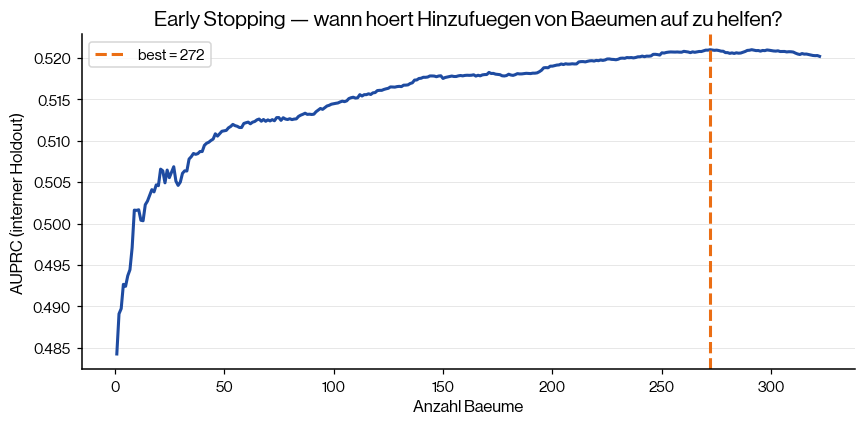

In [ ]:
# =============================================================================
# §6c-1 EARLY STOPPING — datengetriebene Baumanzahl (zeitlicher Holdout in Train)
# =============================================================================
from sklearn.base import clone

cut = int(len(X_train) * 0.85)                  # juengste 15% von Train = interner Stopp-Block
prep_es = clone(preprocessor)
X_es_tr = prep_es.fit_transform(X_train.iloc[:cut])
X_es_ho = prep_es.transform(X_train.iloc[cut:])
y_es_tr = y_train.iloc[:cut]
y_es_ho = y_train.iloc[cut:]

es = XGBClassifier(**XGB_FIXED, max_depth=6, learning_rate=0.05,
                   n_estimators=2000, early_stopping_rounds=50)
es.set_params(eval_metric="aucpr")
es.fit(X_es_tr, y_es_tr, eval_set=[(X_es_ho, y_es_ho)], verbose=False)

best_n_es = int(es.best_iteration) + 1          # best_iteration ist 0-indexiert
print(f"Early Stopping: beste Baumanzahl = {best_n_es}  (AUPRC={es.best_score:.4f})")

# Validierungskurve plotten
_hist = es.evals_result_["validation_0"]["aucpr"]
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, len(_hist) + 1), _hist, color=color("blue"))
ax.axvline(best_n_es, ls="--", color=color("orange"), label=f"best = {best_n_es}")
ax.set_xlabel("Anzahl Baeume"); ax.set_ylabel("AUPRC (interner Holdout)")
ax.set_title("Early Stopping — wann hoert Hinzufuegen von Baeumen auf zu helfen?")
ax.legend(); fig.tight_layout(); fig.savefig(FIG / "06c_early_stopping.png", dpi=150); plt.show()


In [ ]:
# =============================================================================
# §6c-2 RANDOMIZED SEARCH — Hyperparameter auf Zeit-CV (Train-only), Metrik = AP
# =============================================================================
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform, uniform

# Suchpipeline: One-Hot + UNkalibriertes XGB (n_jobs=1 im Modell, Parallelisierung
# uebernimmt die Suche ueber die Kandidaten).
search_pipe = Pipeline([
    ("prep", clone(preprocessor)),
    ("clf", XGBClassifier(**{**XGB_FIXED, "n_jobs": 1}))])

# Suchraum: bewusst breit, aber zentriert um sinnvolle Werte fuer tabellarische Daten.
space = {
    "clf__n_estimators":     [300, 600, 900, max(300, best_n_es)],
    "clf__max_depth":        [3, 4, 5, 6, 8],
    "clf__learning_rate":    loguniform(0.01, 0.3),
    "clf__subsample":        uniform(0.6, 0.4),     # 0.6 .. 1.0
    "clf__colsample_bytree": uniform(0.6, 0.4),     # 0.6 .. 1.0
    "clf__min_child_weight": [1, 3, 5, 10],
    "clf__reg_lambda":       loguniform(0.5, 20),
    "clf__reg_alpha":        loguniform(1e-3, 1.0),
    "clf__gamma":            uniform(0.0, 0.5),
}
N_SEARCH = 10 if FAST_DEV else 40

search = RandomizedSearchCV(
    search_pipe, space, n_iter=N_SEARCH, scoring="average_precision",
    cv=TimeSeriesSplit(n_splits=n_folds), random_state=SEED, n_jobs=-1,
    refit=True, verbose=1)
search.fit(X_train, y_train)

# Top-Konfigurationen als auditierbare Tabelle.
res = (pd.DataFrame(search.cv_results_)
         .sort_values("rank_test_score")
         [["rank_test_score", "mean_test_score", "std_test_score", "params"]]
         .head(10).reset_index(drop=True))
res.to_csv(TAB / "search_results.csv", index=False)
print(f"Beste CV-AP: {search.best_score_:.4f}  (von {N_SEARCH} Konfigurationen)")
BEST_PARAMS = {k.replace("clf__", ""): v for k, v in search.best_params_.items()}
print("Beste Hyperparameter:")
for k, v in BEST_PARAMS.items():
    print(f"   {k:18s} {round(v, 4) if isinstance(v, float) else v}")


Fitting 5 folds for each of 40 candidates, totalling 200 fits
Beste CV-AP: 0.5491  (von 40 Konfigurationen)
Beste Hyperparameter:
   colsample_bytree   0.6888
   gamma              0.0599
   learning_rate      0.0315
   max_depth          5
   min_child_weight   3
   n_estimators       300
   reg_alpha          0.036
   reg_lambda         6.6873
   subsample          0.7455


In [ ]:
# =============================================================================
# §6c-3 BASELINE vs GETUNT auf VAL — und den Gewinner nehmen
# =============================================================================
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss

def fit_calibrated(params):
    """Kalibrierte XGB-Pipeline mit gegebenen Hyperparametern, auf Train gefittet."""
    base = XGBClassifier(**XGB_FIXED, **params)
    cal  = CalibratedClassifierCV(estimator=base, method="isotonic", cv=5)
    return Pipeline([("prep", clone(preprocessor)), ("clf", cal)]).fit(X_train, y_train)

def val_scores(m, label):
    p = m.predict_proba(X_val)[:, 1]
    return {"variante": label, "auc": roc_auc_score(y_val, p),
            "ap": average_precision_score(y_val, p), "brier": brier_score_loss(y_val, p)}

model_base  = fit_calibrated(BASE_PARAMS)
model_tuned = fit_calibrated(BEST_PARAMS)

cmp = pd.DataFrame([val_scores(model_base, "baseline"),
                    val_scores(model_tuned, "getunt")]).round(4)
cmp.to_csv(TAB / "baseline_vs_tuned_val.csv", index=False)
print(cmp.to_string(index=False))

# Gewinner nach Val-AP (mit kleinem Bonus fuer "getunt" nur bei echtem Vorsprung).
_win_tuned = cmp.set_index("variante").loc["getunt", "ap"] >= cmp.set_index("variante").loc["baseline", "ap"]
model       = model_tuned if _win_tuned else model_base
FINAL_PARAMS = BEST_PARAMS if _win_tuned else BASE_PARAMS
print(f"\n--> Final gewaehlt: {'GETUNT' if _win_tuned else 'BASELINE'}  "
      f"(weiter mit diesem Modell in §7-§12)")


variante    auc     ap  brier
baseline 0.8027 0.5453 0.1249
  getunt 0.8079 0.5481 0.1236

--> Final gewaehlt: GETUNT  (weiter mit diesem Modell in §7-§12)


## §7 — Fit auf Train, erste Metriken auf Val

Das finale Modell (gewähltes Setup aus §6c) ist bereits auf Train gefittet. Wir bewerten
auf **Val** — Test bleibt im Tresor. Gleiche Metriken und Definitionen wie 01, damit der
Vergleich in 05 sauber ist: **AUC** (Rangfolge), **AP** (Präzision unter Schieflage),
**Brier** (Ehrlichkeit der Wahrscheinlichkeiten), **Lift@k%** (Trefferdichte fürs
Overbooking).

In [ ]:
# =============================================================================
# §7 VAL-METRIKEN  (model ist aus §6c bereits auf Train gefittet)
# =============================================================================
prob_val = model.predict_proba(X_val)[:, 1]

def lift_at(y_true, prob, frac):
    n = max(1, int(len(prob) * frac))
    top = np.argsort(prob)[::-1][:n]
    return float(np.asarray(y_true)[top].mean() / np.asarray(y_true).mean())

val_metrics = pd.Series({
    "auc":       roc_auc_score(y_val, prob_val),
    "ap":        average_precision_score(y_val, prob_val),
    "brier":     brier_score_loss(y_val, prob_val),
    "lift@5%":   lift_at(y_val, prob_val, 0.05),
    "lift@10%":  lift_at(y_val, prob_val, 0.10),
    "base_rate": float(y_val.mean()),
}, name="val").round(4)
val_metrics.to_csv(TAB / "val_metrics.csv")
print(val_metrics.to_string())


auc          0.8079
ap           0.5481
brier        0.1236
lift@5%      3.6704
lift@10%     3.2302
base_rate    0.1991


## §8 — Threshold-Tuning auf Val

Identisch zu 01. Das Modell liefert Wahrscheinlichkeiten — ab welcher behandeln wir eine
Buchung als "wird storniert"? Diese Schwelle ist eine **Geschäftsentscheidung**. Drei
Betriebspunkte auf **Val**: F1-optimal (neutral), Precision-first (vorsichtiges
Overbooking), Recall-first (aggressiv). Offene Entscheidung #4: später an €-Kosten
koppeln statt an F1.

In [ ]:
# =============================================================================
# §8 DREI BETRIEBSPUNKTE AUF VAL  (identische Logik wie 01)
# =============================================================================
from sklearn.metrics import precision_recall_curve

prec, rec, thr = precision_recall_curve(y_val, prob_val)
prec, rec = prec[:-1], rec[:-1]
f1 = 2 * prec * rec / (prec + rec + 1e-12)

t_f1 = float(thr[np.argmax(f1)])
_ok_p = rec >= 0.50
t_prec = float(thr[_ok_p][np.argmax(prec[_ok_p])])
_ok_r = prec >= 0.50
t_rec = float(thr[_ok_r][np.argmax(rec[_ok_r])])

from src.scoring import cost_threshold_from_scores, cost_at_threshold, COST_WALK, COST_EMPTY
# PRIMARY operating point: minimise FP*C_walk + FN*C_empty on validation (shared
# definition in src.scoring -> comparable across 01/02/03 and matches serving/app).
t_cost = cost_threshold_from_scores(y_val, prob_val, COST_WALK, COST_EMPTY)
_cm = cost_at_threshold(y_val, prob_val, t_cost, COST_WALK, COST_EMPTY)
op_points = pd.DataFrame([
    {"name": "cost_optimal", "threshold": t_cost, "precision": _cm["precision"], "recall": _cm["recall"]},
    {"name": "f1_optimal",   "threshold": t_f1,   "precision": prec[np.argmax(f1)], "recall": rec[np.argmax(f1)]},
]).round(4)
op_points.to_csv(TAB / "operating_points.csv", index=False)
print(op_points.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(thr, prec, label="Precision", color=color("blue"))
ax.plot(thr, rec,  label="Recall",    color=color("orange"))
ax.plot(thr, f1,   label="F1",        color=color("green"))
for t, n in [(t_f1, "F1"), (t_prec, "Prec-first"), (t_rec, "Rec-first")]:
    ax.axvline(t, ls="--", lw=1, color="grey")
    ax.text(t, 1.02, n, rotation=0, ha="center", fontsize=8)
ax.set_xlabel("Threshold (Storno-Wahrscheinlichkeit)"); ax.set_ylabel("Wert")
ax.legend(); ax.set_title("Threshold-Wahl auf Val — drei Betriebspunkte")
fig.tight_layout(); fig.savefig(FIG / "08_threshold_curves.png", dpi=150); plt.show()


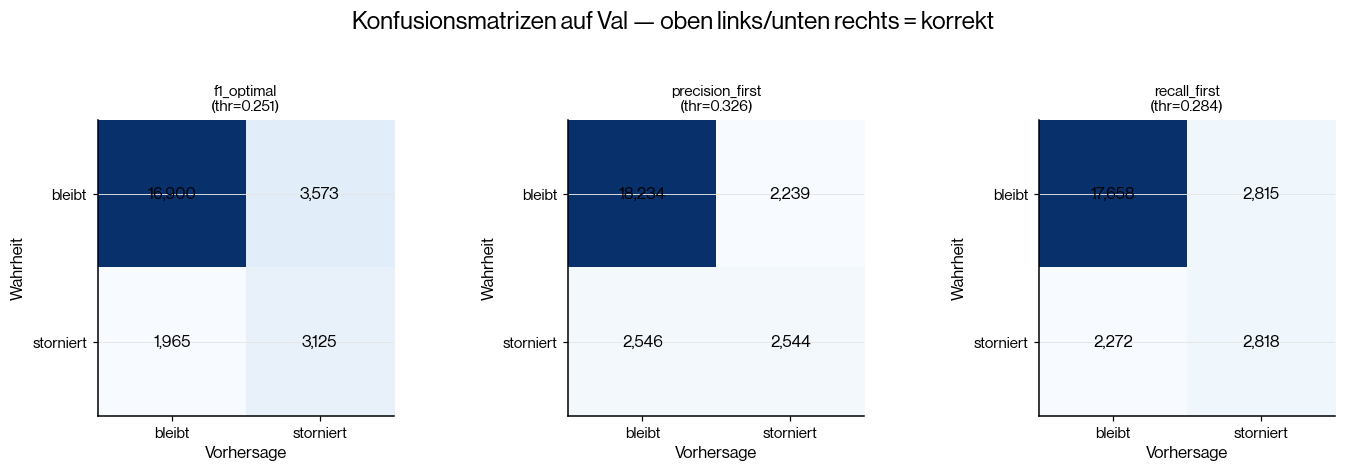

In [ ]:
# =============================================================================
# §8b KONFUSIONSMATRIZEN je Betriebspunkt (auf Val)
# =============================================================================
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (_, row) in zip(axes, op_points.iterrows()):
    pred = (prob_val >= row["threshold"]).astype(int)
    cm = confusion_matrix(y_val, pred)
    ax.imshow(cm, cmap="Blues")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center", color="black", fontsize=11)
    ax.set_title(f"{row['name']}\n(thr={row['threshold']:.3f})", fontsize=10)
    ax.set_xticks([0, 1]); ax.set_xticklabels(["bleibt", "storniert"])
    ax.set_yticks([0, 1]); ax.set_yticklabels(["bleibt", "storniert"])
    ax.set_xlabel("Vorhersage"); ax.set_ylabel("Wahrheit")
fig.suptitle("Konfusionsmatrizen auf Val — oben links/unten rechts = korrekt", y=1.05)
fig.tight_layout(); fig.savefig(FIG / "08_confusion_panel.png", dpi=150, bbox_inches="tight"); plt.show()


## §9 — Finale Bewertung auf Test (einmalig!)

Jetzt — und nur jetzt — öffnen wir den Tresor. Test = neueste 25 %, nie gesehen, keine
Entscheidung darauf getroffen. Drei Diagnose-Plots wie 01: **ROC**, **PR-Kurve**,
**Kalibrierungskurve**. Die auf **Val** fixierten Thresholds werden hier nur *angewendet*,
nicht neu gewählt.

== Headline (Test) ==
auc          0.7894
ap           0.4942
brier        0.1290
lift@5%      3.3791
lift@10%     2.9134
base_rate    0.1975

== Betriebspunkte auf Test ==
           name  threshold  precision  recall     f1
     f1_optimal     0.2505     0.4182  0.6051 0.4946
precision_first     0.3257     0.4801  0.4790 0.4795
   recall_first     0.2843     0.4514  0.5421 0.4926


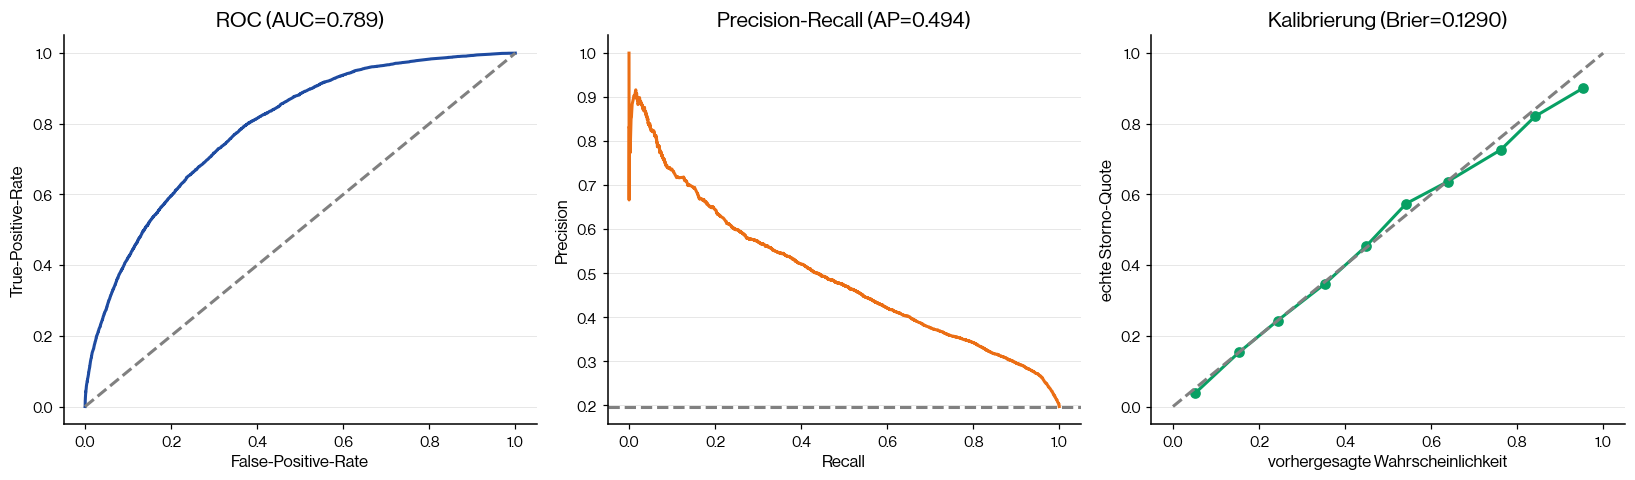

In [ ]:
# =============================================================================
# §9 TEST-METRIKEN + DIAGNOSE-PLOTS  (identische Logik wie 01)
# =============================================================================
from sklearn.metrics import (roc_curve, precision_score, recall_score, f1_score)
from sklearn.calibration import calibration_curve

prob_test = model.predict_proba(X_test)[:, 1]

test_metrics = pd.Series({
    "auc":       roc_auc_score(y_test, prob_test),
    "ap":        average_precision_score(y_test, prob_test),
    "brier":     brier_score_loss(y_test, prob_test),
    "lift@5%":   lift_at(y_test, prob_test, 0.05),
    "lift@10%":  lift_at(y_test, prob_test, 0.10),
    "base_rate": float(y_test.mean()),
}, name="test").round(4)

thr_rows = []
for _, row in op_points.iterrows():
    pred = (prob_test >= row["threshold"]).astype(int)
    thr_rows.append({"name": row["name"], "threshold": row["threshold"],
                     "precision": precision_score(y_test, pred),
                     "recall":    recall_score(y_test, pred),
                     "f1":        f1_score(y_test, pred)})
test_at_thresholds = pd.DataFrame(thr_rows).round(4)

test_metrics.to_csv(TAB / "test_metrics.csv")
test_at_thresholds.to_csv(TAB / "test_at_thresholds.csv", index=False)
print("== Headline (Test) ==");           print(test_metrics.to_string())
print("\n== Betriebspunkte auf Test =="); print(test_at_thresholds.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
fpr, tpr, _ = roc_curve(y_test, prob_test)
axes[0].plot(fpr, tpr, color=color("blue")); axes[0].plot([0, 1], [0, 1], ls="--", color="grey")
axes[0].set_title(f"ROC (AUC={test_metrics['auc']:.3f})")
axes[0].set_xlabel("False-Positive-Rate"); axes[0].set_ylabel("True-Positive-Rate")
p2, r2, _ = precision_recall_curve(y_test, prob_test)
axes[1].plot(r2, p2, color=color("orange")); axes[1].axhline(y_test.mean(), ls="--", color="grey")
axes[1].set_title(f"Precision-Recall (AP={test_metrics['ap']:.3f})")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
frac_pos, mean_pred = calibration_curve(y_test, prob_test, n_bins=10)
axes[2].plot(mean_pred, frac_pos, marker="o", color=color("green")); axes[2].plot([0, 1], [0, 1], ls="--", color="grey")
axes[2].set_title(f"Kalibrierung (Brier={test_metrics['brier']:.4f})")
axes[2].set_xlabel("vorhergesagte Wahrscheinlichkeit"); axes[2].set_ylabel("echte Storno-Quote")
fig.tight_layout(); fig.savefig(FIG / "09_roc_pr_calibration.png", dpi=150); plt.show()


## §10 — Slice-Analyse: Wo ist das Modell gut, wo schwach?

Identisch zu 01. Eine Gesamt-AUC versteckt Schwächen. Fürs Overbooking entscheidend:
funktioniert das Modell **pro Hotel** (dort fällt die Entscheidung), pro Kanal, pro
Lead-Time? Gerade bei **neu eröffneten Häusern** mit wenig Historie: kleine Stichprobe =
unsichere AUC.

        slice                    group     n  cancel_rate    auc
property_name    Berlin Friedrichshain  3946       0.2347 0.7919
property_name   Bielefeld Hauptbahnhof  7415       0.1671 0.7822
property_name         Bochum Ehrenfeld  3247       0.1574 0.7694
property_name           Bremen Am Wall  5447       0.1996 0.7530
property_name        Cologne Ehrenfeld  2997       0.2019 0.8096
property_name             Cologne Sülz  1777       0.2116 0.8524
property_name  Frankfurt Sachsenhausen  4838       0.2702 0.8475
property_name         Fürth Hallstraße   464       0.2177 0.6707
property_name     Gütersloh Langer Weg  3127       0.1689 0.7550
property_name Osnabrück Johannisstraße  6320       0.1771 0.7724
property_name     Wolfsburg Schachtweg  2827       0.2041 0.7382
  channelCode                   Airbnb   989       0.1567 0.7634
  channelCode              Booking.com 19012       0.2355 0.8305
  channelCode                   Direct  3028       0.1139 0.7155
  channelCode            

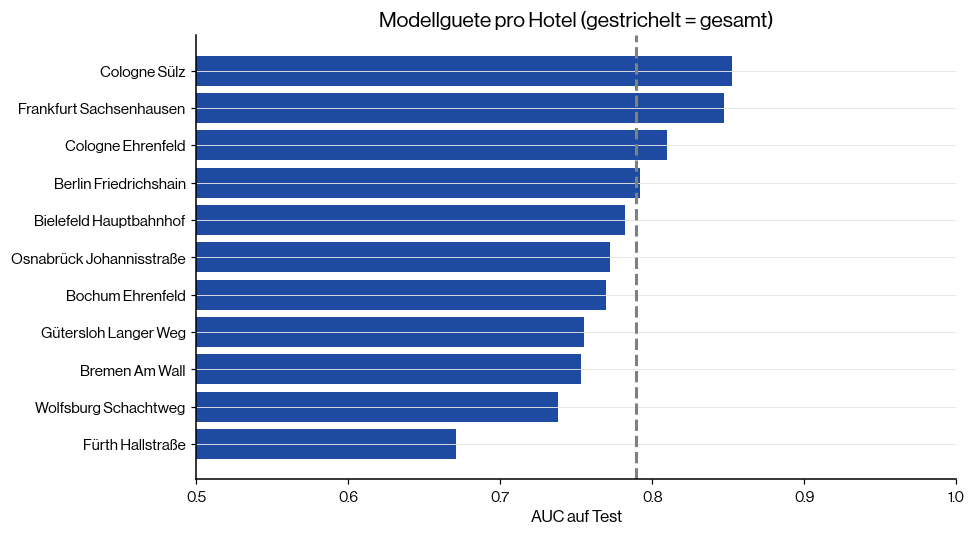

In [ ]:
# =============================================================================
# §10 AUC JE SEGMENT (auf Test)  (identische Logik wie 01)
# =============================================================================
sl = df.loc[m_test, ["property_name", "channelCode", "lead_time_days"]].copy()
sl["y"], sl["p"] = y_test.values, prob_test
sl["lead_bucket"] = pd.cut(sl["lead_time_days"], bins=[-1, 7, 30, 90, 10_000],
                           labels=["0-7d", "8-30d", "31-90d", "90d+"])

def slice_auc(frame, col, min_n=300):
    rows = []
    for g, grp in frame.groupby(col, observed=True):
        if len(grp) >= min_n and grp["y"].nunique() == 2:
            rows.append({"slice": col, "group": str(g), "n": len(grp),
                         "cancel_rate": grp["y"].mean(),
                         "auc": roc_auc_score(grp["y"], grp["p"])})
    return pd.DataFrame(rows)

slices = pd.concat([slice_auc(sl, "property_name"),
                    slice_auc(sl, "channelCode"),
                    slice_auc(sl, "lead_bucket")]).round(4)
slices.to_csv(TAB / "slice_metrics.csv", index=False)
print(slices.to_string(index=False))

_prop = slices[slices["slice"] == "property_name"].sort_values("auc")
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(_prop["group"], _prop["auc"], color=color("blue"))
ax.axvline(test_metrics["auc"], ls="--", color="grey")
ax.set_xlim(0.5, 1.0); ax.set_xlabel("AUC auf Test")
ax.set_title("Modellguete pro Hotel (gestrichelt = gesamt)")
fig.tight_layout(); fig.savefig(FIG / "10_auc_by_property.png", dpi=150); plt.show()


## §11 — Explainability (XAI): *Warum* entscheidet das Modell so?

Vier Blickwinkel — für Bäume teils andere Werkzeuge als bei der LogReg:

1. **Gain-Importances** — der Baum-Heimvorteil: wie viel "Reinheit" bringt jeder Split
   über ein Feature im Schnitt? (ersetzt 01s Koeffizienten). One-Hot-Level werden zur
   Lesbarkeit aufs Eltern-Feature aufsummiert.
2. **Permutation Importance** — Spalte durchmischen → AUC-Verlust. Modellunabhängig,
   identisch zu 01.
3. **PDP/ICE** — Effektkurven der wichtigsten Numerik-Features.
4. **SHAP** — faire Beitragszerlegung pro Buchung. Wir nutzen XGBoosts **exaktes
   TreeSHAP** (`pred_contribs`) statt `shap.TreeExplainer` — das ist versionsrobust und
   unabhängig vom SHAP-internen Modell-Parser.

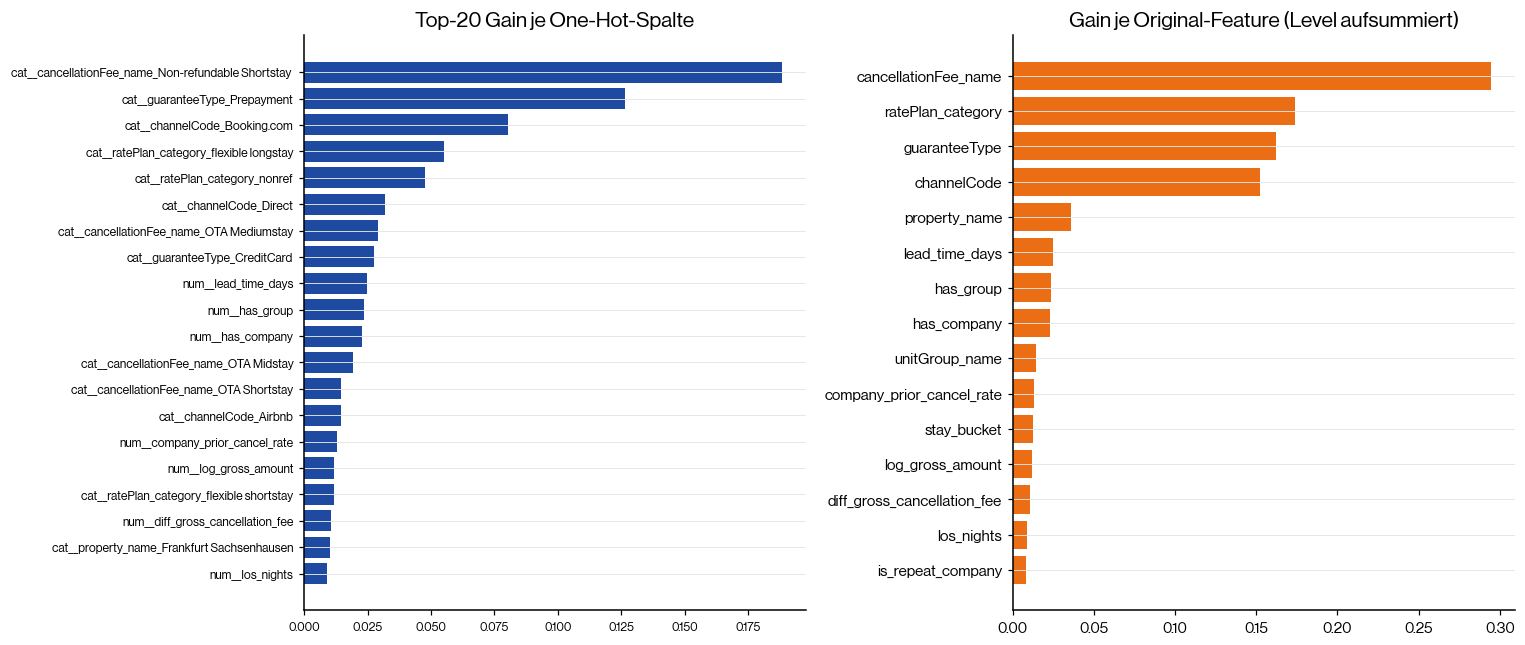

parent
cancellationFee_name         0.2944
ratePlan_category            0.1737
guaranteeType                0.1622
channelCode                  0.1526
property_name                0.0361
lead_time_days               0.0249
has_group                    0.0234
has_company                  0.0228
unitGroup_name               0.0145
company_prior_cancel_rate    0.0131


In [ ]:
# =============================================================================
# §11a GAIN-IMPORTANCES — gemittelt ueber die 5 Kalibrier-Falten (wie 01 bei coef)
# =============================================================================
cals  = model.named_steps["clf"].calibrated_classifiers_
imps  = np.vstack([c.estimator.feature_importances_ for c in cals])  # 5 x n_spalten
imp_mean = imps.mean(axis=0)
feat_names = list(model.named_steps["prep"].get_feature_names_out())

imp_df = (pd.DataFrame({"feature": feat_names, "gain": imp_mean})
            .sort_values("gain", ascending=False))
imp_df.to_csv(TAB / "feature_importances.csv", index=False)

# One-Hot-Level aufs Eltern-Feature zusammenfassen (Gain summieren).
def _parent(nm):
    if nm.startswith("cat__"):
        core = nm[len("cat__"):]
        return next((c for c in CAT_FEATURES if core.startswith(c + "_")), core)
    return nm.replace("num__", "")
imp_parent = (imp_df.assign(parent=imp_df["feature"].map(_parent))
                    .groupby("parent")["gain"].sum()
                    .sort_values(ascending=False))
imp_parent.to_csv(TAB / "feature_importances_by_feature.csv")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
top_lvl = imp_df.head(20).iloc[::-1]
axes[0].barh(top_lvl["feature"], top_lvl["gain"], color=color("blue"))
axes[0].set_title("Top-20 Gain je One-Hot-Spalte"); axes[0].tick_params(labelsize=8)
top_par = imp_parent.head(15).iloc[::-1]
axes[1].barh(top_par.index, top_par.values, color=color("orange"))
axes[1].set_title("Gain je Original-Feature (Level aufsummiert)")
fig.tight_layout(); fig.savefig(FIG / "11_gain_importance.png", dpi=150, bbox_inches="tight"); plt.show()
print(imp_parent.head(10).round(4).to_string())


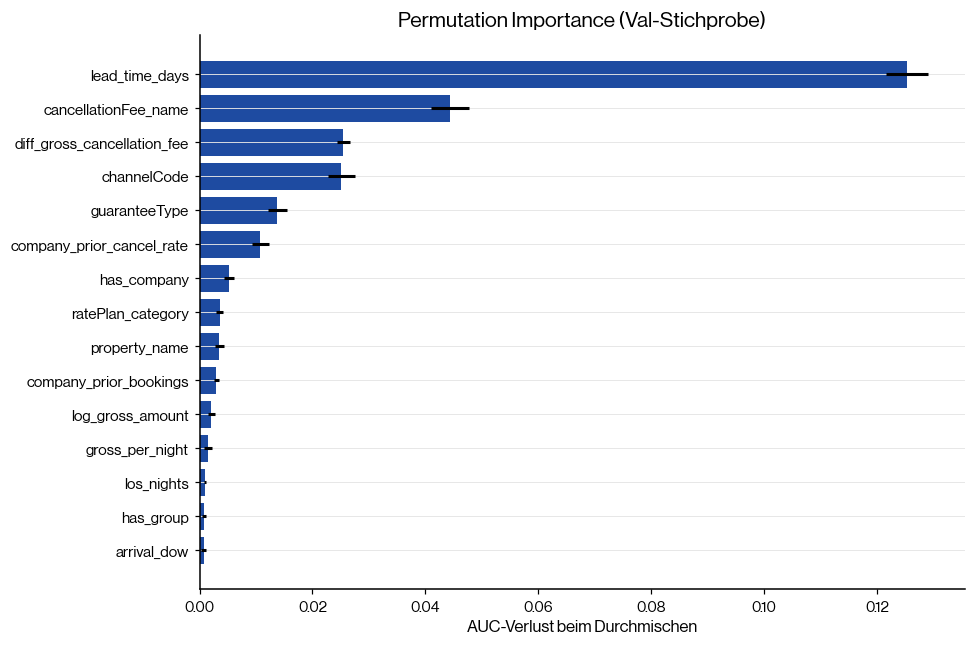

In [ ]:
# =============================================================================
# §11b PERMUTATION IMPORTANCE — worauf stuetzt sich das Modell? (Val-Stichprobe)
# =============================================================================
from sklearn.inspection import permutation_importance

_n = min(5000, len(X_val))
Xs = X_val.sample(_n, random_state=SEED)
ys = y_val.loc[Xs.index]
perm = permutation_importance(model, Xs, ys, scoring="roc_auc",
                              n_repeats=5, random_state=SEED, n_jobs=1)

perm_df = (pd.DataFrame({"feature": FEATURES,
                         "auc_drop_mean": perm.importances_mean,
                         "auc_drop_std":  perm.importances_std})
             .sort_values("auc_drop_mean", ascending=False))
perm_df.to_csv(TAB / "permutation_importance.csv", index=False)

top = perm_df.head(15).iloc[::-1]
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top["feature"], top["auc_drop_mean"], xerr=top["auc_drop_std"], color=color("blue"))
ax.set_xlabel("AUC-Verlust beim Durchmischen")
ax.set_title("Permutation Importance (Val-Stichprobe)")
fig.tight_layout(); fig.savefig(FIG / "11_permutation_importance.png", dpi=150); plt.show()


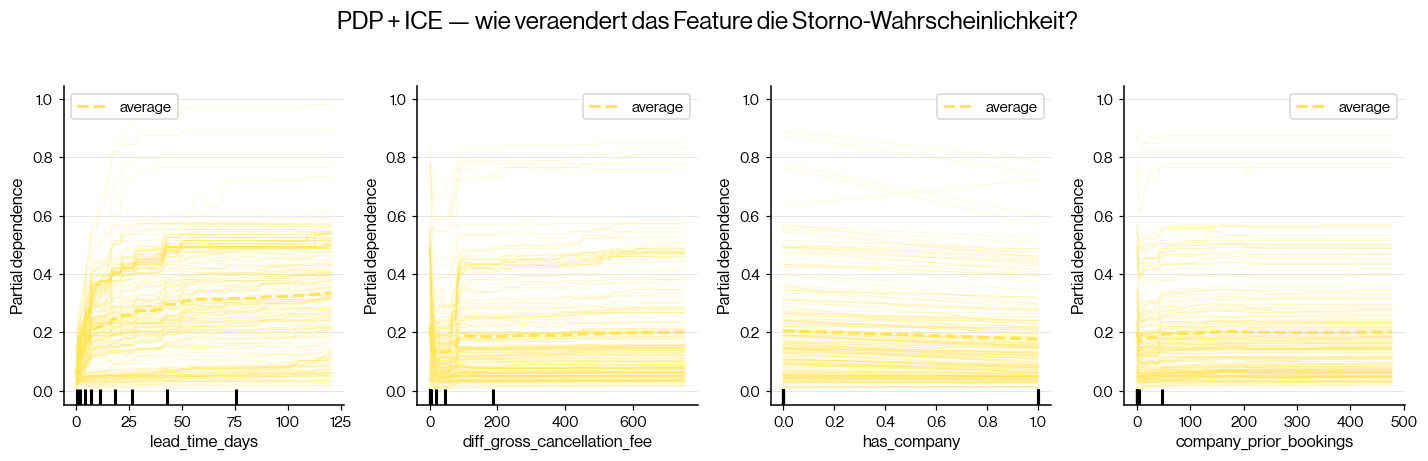

In [ ]:
# =============================================================================
# §11c PDP + ICE — Effektkurven der wichtigsten numerischen Features
# =============================================================================
from sklearn.inspection import PartialDependenceDisplay

top_num = [f for f in perm_df["feature"] if f in NUM_FEATURES][:4]
fig, axes = plt.subplots(1, len(top_num), figsize=(13, 4))
PartialDependenceDisplay.from_estimator(
    model, X_val.sample(min(1000, len(X_val)), random_state=SEED),
    features=top_num, kind="both", subsample=200, random_state=SEED, ax=axes)
fig.suptitle("PDP + ICE — wie veraendert das Feature die Storno-Wahrscheinlichkeit?", y=1.04)
fig.tight_layout(); fig.savefig(FIG / "11_pdp_ice.png", dpi=150, bbox_inches="tight"); plt.show()


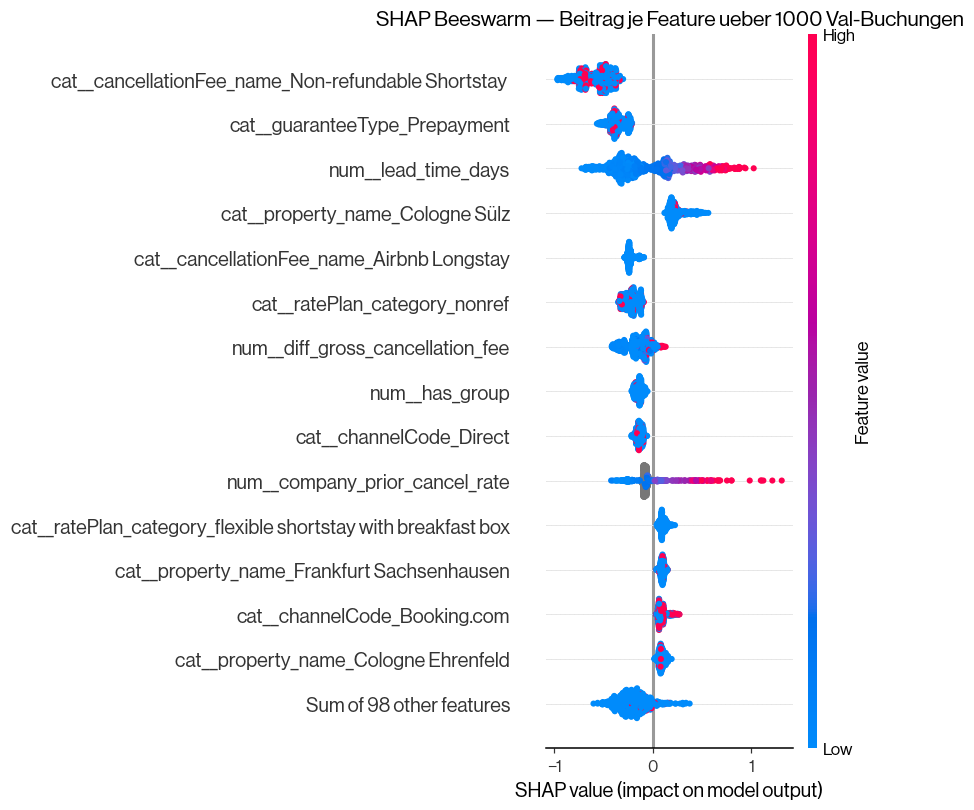

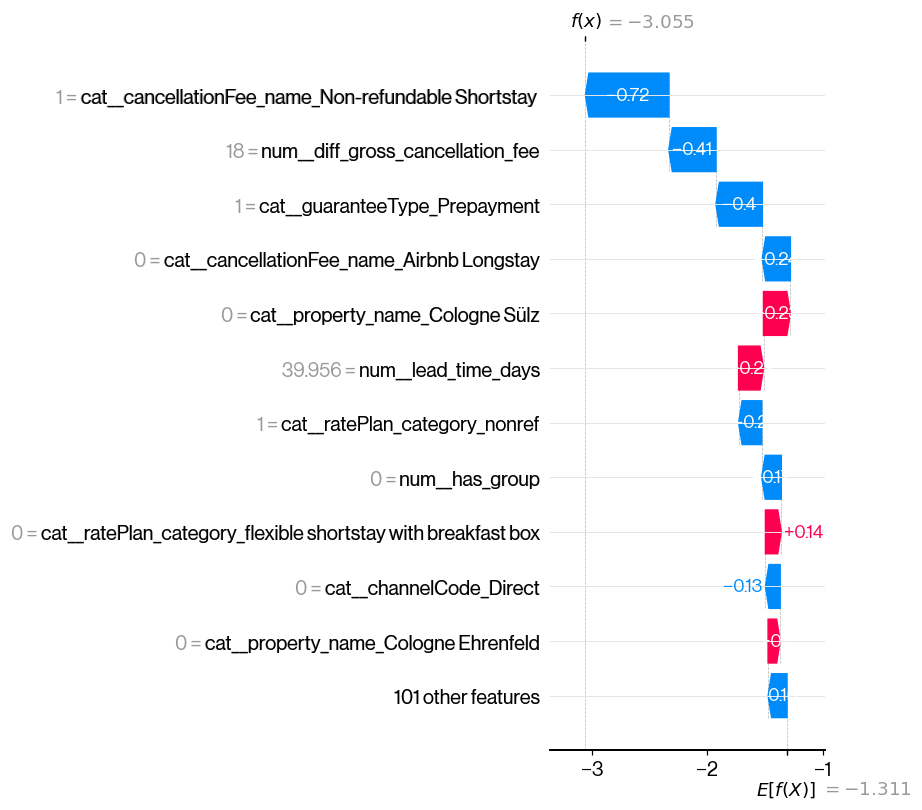

In [ ]:
# =============================================================================
# §11d SHAP — exaktes TreeSHAP via XGBoost (pred_contribs), versionsrobust
# =============================================================================
import shap
from xgboost import DMatrix

# Wir erklaeren das UNkalibrierte Basis-XGB der ersten Kalibrier-Falte (die Kalibrierung
# ist eine monotone Nachkorrektur und aendert nicht, WELCHE Features eine Buchung riskant
# machen). pred_contribs liefert exakte TreeSHAP-Werte, ohne SHAPs Modell-Parser.
base_shap = model.named_steps["clf"].calibrated_classifiers_[0].estimator

Xs   = X_val.sample(min(1000, len(X_val)), random_state=SEED)
Xenc = model.named_steps["prep"].transform(Xs)
Xarr = Xenc.toarray() if hasattr(Xenc, "toarray") else np.asarray(Xenc)

# DMatrix OHNE feature_names (Sonderzeichen in Kategorien wuerden XGB sonst stoeren) —
# die Spaltenreihenfolge entspricht feat_names; Namen setzen wir erst in der Explanation.
contribs   = base_shap.get_booster().predict(DMatrix(Xarr), pred_contribs=True)
shap_vals  = contribs[:, :-1]          # letzte Spalte = Bias/Basiswert
base_vals  = contribs[:, -1]
expl = shap.Explanation(values=shap_vals, base_values=base_vals,
                        data=Xarr, feature_names=feat_names)

shap.plots.beeswarm(expl, max_display=15, show=False)
plt.title("SHAP Beeswarm — Beitrag je Feature ueber 1000 Val-Buchungen")
plt.gcf().tight_layout(); plt.gcf().savefig(FIG / "11_shap_beeswarm.png", dpi=150, bbox_inches="tight"); plt.show()

shap.plots.waterfall(expl[0], max_display=12, show=False)
plt.gcf().tight_layout(); plt.gcf().savefig(FIG / "11_shap_waterfall.png", dpi=150, bbox_inches="tight"); plt.show()


## §12 — Artefakte speichern

Wie 01 — gleiche Dateinamen-Konvention, damit das Vergleichs-Notebook (05), die App und
`src/scoring.py` die Modelle einheitlich finden:

- **Modell** (`02_xgboost_model.joblib`) — komplette Pipeline (Preprocessing + kalibriertes XGB)
- **Predictions** (Val + Test) — fürs faire Vergleichs-Notebook (exakt gleiche Zeilen)
- **Model Card** (JSON) — Datenfenster, Splits, Features, *gewählte* Hyperparameter,
  Tuning-Provenienz (Encoding-Wahl, CV-AP), Metriken, Thresholds. Unser Audit-Log.

In [ ]:
# =============================================================================
# §12 PERSISTIEREN  (gleiche Konvention wie 01)
# =============================================================================
import joblib
from src import data_dir
import sklearn, xgboost

# (1) Komplette Pipeline.
joblib.dump(model, data_dir() / "02_xgboost_model.joblib")

# (2) Val- + Test-Predictions mit Kontext (Block-getrennt -> Zuordnung garantiert korrekt).
_ctx = ["arrival", "property_name", "lead_time_days", "temporal_split"]
pred_val  = df.loc[m_val,  _ctx].copy()
pred_val["y_true"], pred_val["y_prob"]   = y_val.values,  prob_val
pred_test = df.loc[m_test, _ctx].copy()
pred_test["y_true"], pred_test["y_prob"] = y_test.values, prob_test
pred = pd.concat([pred_val, pred_test])
pred.to_parquet(data_dir() / "02_xgboost_predictions.parquet")

# (3) Model Card.
model_card = {
    "model":           "xgboost_onehot_isotonic",
    "notebook":        "02_xgboost.ipynb",
    "trained_at":      pd.Timestamp.now(tz="UTC").isoformat(),
    "sklearn_version": sklearn.__version__,
    "xgboost_version": xgboost.__version__,
    "fast_dev":        FAST_DEV,
    "n_train":         int(len(X_train)),
    "n_val":           int(len(X_val)),
    "n_test":          int(len(X_test)),
    "features_numeric":     NUM_FEATURES + NUM_HISTORY,
    "features_categorical": CAT_FEATURES,
    "encoding":        "onehot (cat) + passthrough (num, history NaN native)",
    "hyperparams":     {**XGB_FIXED, **FINAL_PARAMS, "calibration": "isotonic_cv5"},
    "tuning": {
        "selected": "tuned" if FINAL_PARAMS is not BASE_PARAMS else "baseline",
        "search_n_iter": int(N_SEARCH),
        "best_cv_ap": float(search.best_score_),
        "early_stopping_best_n": int(best_n_es),
        "encoding_benchmark": enc_table.to_dict(orient="records"),
    },
    "val_metrics":      val_metrics.to_dict(),
    "test_metrics":     test_metrics.to_dict(),
    "operating_points": op_points.to_dict(orient="records"),
}
(TAB / "model_card.json").write_text(json.dumps(model_card, indent=2, default=str))

print("Gespeichert: Modell, Predictions (val+test), Model Card.")
print(f"Test-AUC = {test_metrics['auc']:.4f} | AP = {test_metrics['ap']:.4f} | Brier = {test_metrics['brier']:.4f}")


Gespeichert: Modell, Predictions (val+test), Model Card.
Test-AUC = 0.7894 | AP = 0.4942 | Brier = 0.1290


## §13 - Conclusion & open discussion points

*(Fill in after the full run / discuss in chat.)*

**Result summary:** Test-AUC ___ · AP ___ · Brier ___ · Lift@10% ___
→ Comparison to the LogReg baseline (01): better/worse by ___?

**What distinguishes XGBoost methodologically from 01 (and why):**

1. **History feature with native NaN** instead of 0-filling - separates "no history" from
   "0% cancellation rate". The isolated effect is shown by comparing the `gain`/SHAP contributions
   of `company_prior_cancel_rate` against 01.
2. **No scaling, One-Hot empirically confirmed** (§6b) - at low cardinality the encoding
   effect was within the noise.
3. **Tuned instead of default** (§6c) - baseline vs. tuned is documented in
   `baseline_vs_tuned_val.csv`; the final configuration is in the model card.

**Open decisions (some shared with 01):**

1. `ratePlan_category` (35) vs. `ratePlan_type` (6) - finer vs. more robust (open #1).
2. Threshold economically (€-cost) instead of F1 (open #4).
3. Search space / `n_iter` of the hyperparameter search - searching wider only pays off if §6c
   shows a clear gradient.
4. **Train/serve parity:** `src/scoring.py build_features` does not yet compute the company-history
   bundle → the scorer currently cannot serve the 24-feature model.
   This is a known open point (modelling-phase TODO), independent of 02.

**Next step:** 03 (HistGradientBoosting) - same framework, native categories +
native NaN, permutation-based XAI (HistGB has no `feature_importances_`).

## §13 — Fazit & offene Diskussionspunkte

*(Nach dem Volllauf ausfüllen / im Chat diskutieren.)*

**Ergebnis-Zusammenfassung:** Test-AUC ___ · AP ___ · Brier ___ · Lift@10% ___
→ Vergleich zur LogReg-Baseline (01): besser/schlechter um ___?

**Was XGBoost methodisch von 01 unterscheidet (und warum):**

1. **History-Feature mit nativem NaN** statt 0-Füllung — trennt "keine Historie" von
   "0 % Stornoquote". Den isolierten Effekt zeigt der Vergleich der `gain`/SHAP-Beiträge
   von `company_prior_cancel_rate` gegenüber 01.
2. **Kein Scaling, One-Hot empirisch bestätigt** (§6b) — bei niedriger Kardinalität war
   der Encoding-Effekt im Rauschen.
3. **Getunt statt Default** (§6c) — Baseline vs. getunt ist in `baseline_vs_tuned_val.csv`
   dokumentiert; die finale Konfiguration steht in der Model Card.

**Offene Entscheidungen (teils geteilt mit 01):**

1. `ratePlan_category` (35) vs. `ratePlan_type` (6) — feiner vs. robuster (offene #1).
2. Threshold ökonomisch (€-Kosten) statt F1 (offene #4).
3. Suchraum/`n_iter` der Hyperparameter-Suche — breiter suchen lohnt nur, wenn §6c
   einen klaren Gradienten zeigt.
4. **Train/Serve-Parität:** `src/scoring.py build_features` berechnet das Company-History-
   Bundle noch nicht → der Scorer kann das 24-Feature-Modell aktuell nicht bedienen.
   Das ist ein bekannter offener Punkt (Modelling-phase TODO), unabhängig von 02.

**Nächster Schritt:** 03 (HistGradientBoosting) — gleiches Gerüst, native Kategorien +
nativer NaN, Permutation-basierte XAI (HistGB hat keine `feature_importances_`).

## §13 Walk-forward evaluation + deployment model (v11)

Routes the production model + honest forward metrics through `src.training` (same code the app's retrain calls). `mode="retune"` re-searches hyperparameters; the app uses `mode="refit"`. Heavy — several minutes.

In [ ]:
# Walk-forward eval + DEPLOYMENT fit via src.training (same path the app calls).
import src.training as T
MODEL = "xgboost"
deploy = T.retrain(MODEL, mode="retune")
import pandas as pd
display(pd.DataFrame(deploy["walk_forward"]["per_fold"]))
print("walk-forward aggregate (mean ± std):")
for _m,_v in deploy["walk_forward"]["aggregate"].items():
    print(f"  {_m:6s} {_v['mean']:.4f} ± {_v['std']:.4f}")
print("\ndeployment model persisted ->", deploy["persisted"]["joblib"])
print("trained on", deploy["n_train_deploy"], "rows | feature_change:", deploy["feature_change"]["changed"])